['beauti', 'sunflow', 'sunni', 'friday', 'morn', ':)', 'sunflow', 'favourit', 'happi', 'friday', '…']


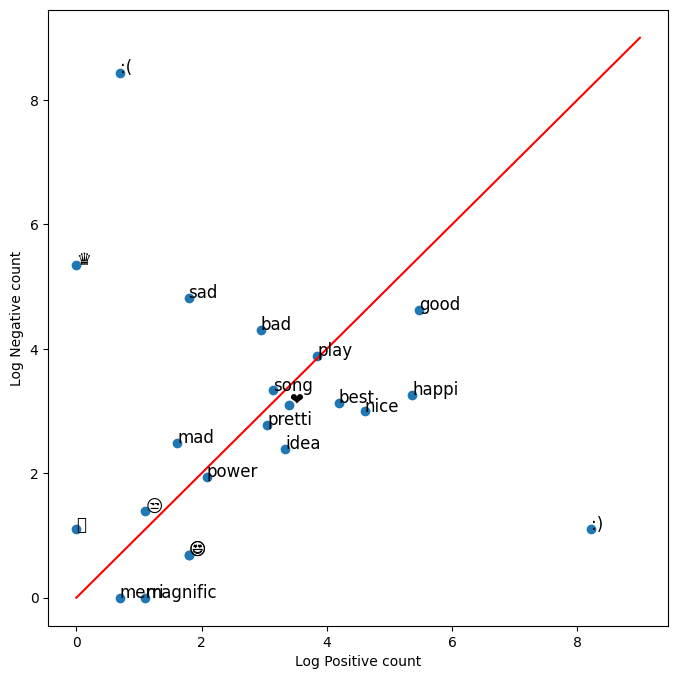

In [2]:
import nltk
from nltk.corpus import twitter_samples, stopwords
import matplotlib.pyplot as plt
import random
import re                                  # library for regular expression operations
import string                              # for string operations
from nltk.stem import PorterStemmer        # module for stemming
from nltk.tokenize import TweetTokenizer   # module for tokenizing strings
import numpy as np
# downloads sample twitter dataset.
# nltk.download('twitter_samples')

# download the stopwords from NLTK
# nltk.download('stopwords')
plt.close()


def process_tweet(tweet):
    # remove old style retweet text "RT"
    tweet2 = re.sub(r'^RT[\s]+', '', tweet)

    # remove hyperlinks
    tweet2 = re.sub(r'https?://[^\s\n\r]+', '', tweet2)

    # remove hashtags
    # only removing the hash # sign from the word
    tweet2 = re.sub(r'#', '', tweet2)

    # instantiate tokenizer class
    tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True,
                               reduce_len=True)

    # tokenize tweets
    tweet_tokens = tokenizer.tokenize(tweet2)

    # Import the english stop words list from NLTK
    stopwords_english = stopwords.words('english')

    # print('Stop words\n')
    # print(stopwords_english)

    # print('\nPunctuation\n')
    # print(string.punctuation)

    tweets_clean = []

    for word in tweet_tokens:  # Go through every word in your tokens list
        if (word not in stopwords_english and  # remove stopwords
                word not in string.punctuation):  # remove punctuation
            tweets_clean.append(word)

    # Instantiate stemming class
    stemmer = PorterStemmer()

    # Create an empty list to store the stems
    tweets_stem = []

    for word in tweets_clean:
        stem_word = stemmer.stem(word)  # stemming word
        tweets_stem.append(stem_word)  # append to the list

    return tweets_stem


def build_freqs(tweets, ys):
    """Build frequencies.
    Input:
        tweets: a list of tweets
        ys: an m x 1 array with the sentiment label of each tweet
            (either 0 or 1)
    Output:
        freqs: a dictionary mapping each (word, sentiment) pair to its
        frequency
    """
    # Convert np array to list since zip needs an iterable.
    # The squeeze is necessary or the list ends up with one element.
    # Also note that this is just a NOP if ys is already a list.
    yslist = np.squeeze(ys).tolist()

    # Start with an empty dictionary and populate it by looping over all tweets
    # and over all processed words in each tweet.
    freqs = {}
    for y, tweet in zip(yslist, tweets):
        for word in process_tweet(tweet):
            pair = (word, y)
            if pair in freqs:
                freqs[pair] += 1
            else:
                freqs[pair] = 1
    return freqs


def plot_freq(data):
    fig, ax = plt.subplots(figsize=(8, 8))

    # convert positive raw counts to logarithmic scale. we add 1 to avoid log(0)
    x = np.log([x[1] + 1 for x in data])

    # do the same for the negative counts
    y = np.log([x[2] + 1 for x in data])

    # Plot a dot for each pair of words
    ax.scatter(x, y)

    # assign axis labels
    plt.xlabel("Log Positive count")

    plt.ylabel("Log Negative count")

    # Add the word as the label at the same position as you added the points just before
    for i in range(0, len(data)):
        ax.annotate(data[i][0], (x[i], y[i]), fontsize=12)

    # Plot the red line that divides the 2 areas.
    ax.plot([0, 9], [0, 9], color='red')
    plt.show()
    plt.close()


def frequency_analysis(freqs):

    # select some words to appear in the report. we will assume that each word is unique (i.e. no duplicates)
    keys = ['happi', 'merri', 'nice', 'good', 'bad', 'sad', 'mad', 'best', 'pretti',
            '❤', ':)', ':(', '😒', '😬', '😄', '😍', '♛',
            'song', 'idea', 'power', 'play', 'magnific']

    # list representing our table of word counts.
    # each element consist of a sublist with this pattern: [<word>, <positive_count>, <negative_count>]
    data = []

    # loop through our selected words
    for word in keys:

        # initialize positive and negative counts
        pos = 0
        neg = 0

        # retrieve number of positive counts
        if (word, 1) in freqs:
            pos = freqs[(word, 1)]

        # retrieve number of negative counts
        if (word, 0) in freqs:
            neg = freqs[(word, 0)]

        # append the word counts to the table
        data.append([word, pos, neg])
    plot_freq(data)


if __name__ == '__main__':
    # select the set of positive and negative tweets
    all_positive_tweets = twitter_samples.strings('positive_tweets.json')
    all_negative_tweets = twitter_samples.strings('negative_tweets.json')

    tweet = all_positive_tweets[2277]
    proccessed_sentence = process_tweet(tweet)
    print(proccessed_sentence)

    # Frequency dict
    tweets = all_positive_tweets + all_negative_tweets
    # make a numpy array representing labels of the tweets
    labels = np.append(np.ones((len(all_positive_tweets))),
                       np.zeros((len(all_negative_tweets))))
    
    freqs = build_freqs(tweets, labels)
    
    frequency_analysis(freqs)


In [3]:
import pandas as pd

df = pd.read_csv("test.csv")

In [4]:
df

,index,name,count
0,0,Chethan,3
1,1,Rockm,4


In [5]:
print("hel")

hel


In [6]:
import numpy as np

In [10]:
a = np.array([1,2,3]).reshape(-1,1)

In [11]:
a

array([[1],
       [2],
       [3]])

In [12]:
a.shape

(3, 1)

In [13]:
b = 2*a
b

array([[2],
       [4],
       [6]])

In [14]:
a + b

array([[3],
       [6],
       [9]])

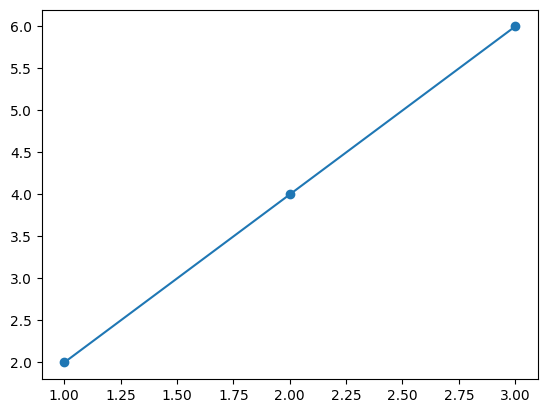

In [16]:
import matplotlib.pyplot as plt
plt.plot(a,b)
plt.scatter(a,b)

In [17]:
!pip install sympy


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [18]:
from sympy import *
init_printing()
x, y, z, t = symbols('x y z t')
k, m, n = symbols('k m n', integer=True)
f, g, h = symbols('f g h', cls=Function)

In [19]:
x,y,z

$$
x = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a}
$$

The function is defined as:

$$
f = \int_{0}^{10} (x^2 + 4x - x^3) \, dx
$$

